# Posture Clustering - Interactive Training

This notebook shows how to train posture clustering models and explore clusters interactively.

**Goal**: Identify which clusters represent GOOD vs BAD postures.


In [ ]:
# Setup
from scripts.train_posture_clustering import (
    train_clustering, 
    plot_elbow_curve,
    InteractiveClusterExplorer,
    save_trained_models
)


## 1. Find Optimal Number of Clusters


📊 Loading training data...
   ✅ Loaded 84963 samples with 34 features
📈 Calculating elbow curve...
   K=1: WCSS=2761995
   K=2: WCSS=2417428
   K=3: WCSS=2276621
   K=4: WCSS=1608572
   K=5: WCSS=1529492
   K=6: WCSS=1475771
   K=7: WCSS=1429369
   K=8: WCSS=1330410


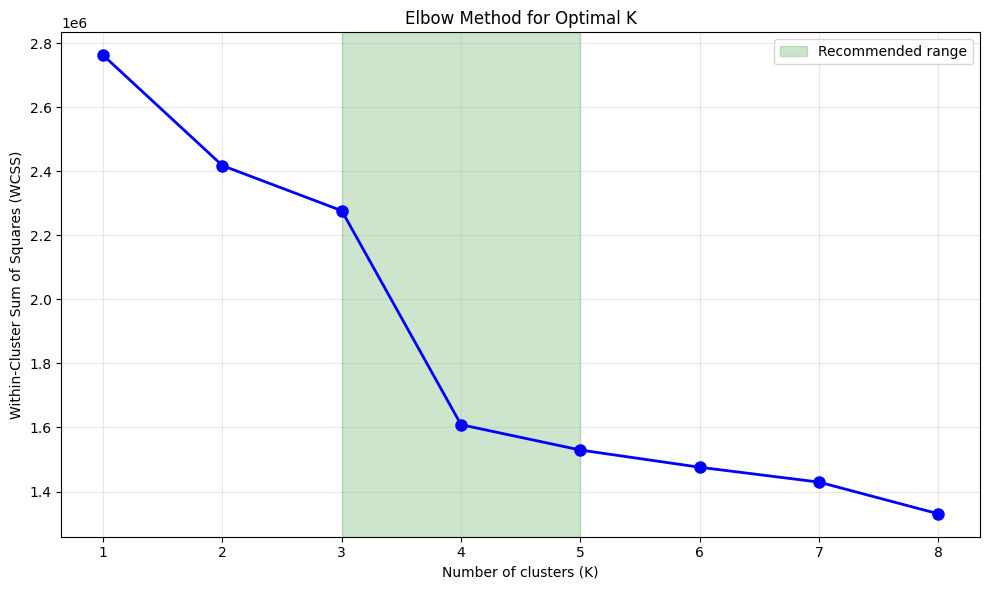

In [2]:
# Plot elbow curve to choose K
wcss = plot_elbow_curve(max_k=8)


## 2. Train Clustering Models


In [3]:
# Train with chosen number of clusters
results = train_clustering(n_clusters=4)  # Adjust based on elbow curve


📊 Loading training data...
   ✅ Loaded 84963 samples with 34 features
🤖 Training clustering models...
   - Features: (84963, 34)
   - Clusters: 4
   - PCA variance: 0.95
   ✅ Scaled features
   ✅ PCA: 34 → 17 components (95.6% variance)
   ✅ K-means clustering complete

📊 Cluster distribution:
   Cluster 0: 43192 samples (50.8%)
   Cluster 1: 39719 samples (46.7%)
   Cluster 2: 2051 samples (2.4%)
   Cluster 3: 1 samples (0.0%)


## 3. Interactive Cluster Exploration

Use the interactive widget below to explore each cluster and identify good vs bad postures:


In [4]:
# Create interactive explorer
explorer = InteractiveClusterExplorer(results)
explorer.show()


📊 Loading training data...
   ✅ Loaded 84963 samples with 34 features


## 4. Save Models

After identifying good clusters, save the models:


In [5]:
# Save trained models
save_trained_models(results)

print("✅ Models saved!")
print("📝 Remember to update predict_posture.py if good clusters changed from [1, 2]")


💾 Models saved to: trained_models/keypoint_models
✅ Models saved!
📝 Remember to update predict_posture.py if good clusters changed from [1, 2]


## 5. Quick Test

Test the saved models:


In [ ]:
# Test prediction
from scripts.predict_posture import predict_posture
from helpers.load_waybetter_db import load_keypoints_db, load_bounding_boxes_db

#Load test data
keypoints_df = load_keypoints_db().head(5)
bounding_boxes_df = load_bounding_boxes_db()

# Predict
results = predict_posture(keypoints_df, bounding_boxes_df)

print("Test results:")
print(f"Clusters: {results['clusters']}")
print(f"Good posture: {results['good_posture']}")


Test results:
Clusters: [0 0 0 1 0]
Good posture: [False False False  True False]
